In [1]:
import h5py
import xarray as xr
import imageio
import matplotlib.pyplot as plt
import os
import numpy as np
import tidy3d as td
import matplotlib
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from scipy.fft import fftn, ifftn, fftshift
from scipy.interpolate import interp1d
from scipy.signal import argrelextrema
import sys
import scipy
from scipy.ndimage import gaussian_filter1d
# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
plt.rc('font', family='Arial')

In [2]:
# data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90.h5")
data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90_absorbers.h5")

In [3]:
data.keys()

dict_keys(['2.90'])

In [4]:
gap_data = AM.read_hdf5_as_dict(rf"../../20250630 MPB Bands analysis/Data/gap_data.hdf5")
gaps_ff_22_n_2p90=14.3/(gap_data["Circular"]["0.22"]["gap_edges"][np.where(gap_data["Circular"]["0.22"]["n"]==2.9)[0]]).flatten()

In [5]:
a=2.562629142772549
gap_center = a/(np.sum(gaps_ff_22_n_2p90)/2)

a/gaps_ff_22_n_2p90

array([0.43214708, 0.46009945])

In [6]:
def diameter(intensity_array,x,y):
    intensity = intensity_array
    integral_1 = scipy.integrate.simpson(scipy.integrate.simpson(intensity**2, x=y, axis=1), x=x, axis=0)
    integral_2 = scipy.integrate.simpson(scipy.integrate.simpson(intensity, x=y, axis=1), x=x, axis=0)**2
    
    return 2*np.sqrt((integral_2/integral_1)/np.pi)


def diameter_sigma(intensity_array, x, y):
    """Beam width from the second moment (standard deviation) of the intensity
    distribution, instead of the participation ratio used by ``diameter``.

    The intensity is treated as an (unnormalized) 2D probability density over
    the (x, y) plane. The intensity-weighted centroid is computed, then the
    radial RMS spread

        sigma_r = sqrt(sigma_x**2 + sigma_y**2)

    with sigma_x**2 = <(x - x_mean)**2> and sigma_y**2 = <(y - y_mean)**2> the
    intensity-weighted variances. All integrals use the same Simpson scheme as
    ``diameter`` (axis 0 -> x, axis 1 -> y).

    Parameters
    ----------
    intensity_array : ndarray of shape (nx, ny) -- intensity I(x, y).
    x, y : 1D coordinate arrays along axis 0 and axis 1.

    Returns
    -------
    sigma_r : RMS radius (standard deviation) of the distribution, in the units
              of x / y. For a D4-sigma beam diameter use 4 * sigma_r.
    """
    intensity = intensity_array
    X = np.asarray(x)[:, None]
    Y = np.asarray(y)[None, :]

    # zeroth moment (total power) — normalization
    norm = scipy.integrate.simpson(scipy.integrate.simpson(intensity, x=y, axis=1), x=x, axis=0)

    # first moments — intensity-weighted centroid
    x_mean = scipy.integrate.simpson(scipy.integrate.simpson(X * intensity, x=y, axis=1), x=x, axis=0) / norm
    y_mean = scipy.integrate.simpson(scipy.integrate.simpson(Y * intensity, x=y, axis=1), x=x, axis=0) / norm

    # second central moments — variances
    var_x = scipy.integrate.simpson(scipy.integrate.simpson((X - x_mean)**2 * intensity, x=y, axis=1), x=x, axis=0) / norm
    var_y = scipy.integrate.simpson(scipy.integrate.simpson((Y - y_mean)**2 * intensity, x=y, axis=1), x=x, axis=0) / norm

    return 2*np.sqrt(var_x + var_y)


def moving_average(x, w=3):
    if w <= 1:
        return x
    return np.convolve(x, np.ones(w), 'valid') / w

In [7]:
from scipy.fft import fft  # forward FFT inverts Tidy3D's exp(+2*pi*i*f*t) DFT convention
from scipy.signal.windows import gaussian, tukey

def diameter_time_domain(field, a, nu_center=None, delta_nu=0.3,
                         intensity_floor=1e-12, chunk=64, window="hann",
                         oversample=1,diameter_type="full_width_half_maximum"):
    """Reconstruct the time-domain beam diameter ``d(t)`` from the
    frequency-domain field.

    A window of normalized width ``delta_nu`` (in units of ``a/lambda = a*f/c``)
    is selected from the spectrum and Fourier transformed back to the time
    domain.  The uniform frequency spacing ``df`` of the stored band sets the
    time window  ``T = 1/df`` (~20 ps here, the original simulation duration),
    while the window bandwidth  ``delta_f = delta_nu * c / a``  sets the time
    resolution  ``dt = 1/delta_f``.

    ``oversample`` zero-pads the windowed spectrum by that integer factor before
    the FFT.  This sinc-interpolates the time axis onto ``Nfft = oversample*Nwin``
    points (finer ``dt``) **without changing** the total span ``T = 1/df`` -- it
    only makes ``d(t)`` smoother, it does NOT resolve features finer than the
    true ``1/delta_f`` set by the window bandwidth.  ``oversample=1`` (default)
    reproduces the un-padded result.

    Tidy3D stores the spectrum with the ``exp(+2*pi*i*f*t)`` convention, so the
    forward ``fft`` is the correct inverse and produces a forward-running time
    axis ``t`` in ``[0, T)``. The (carrier) phase from the non-zero start
    frequency cancels in ``|E(t)|**2``, which is the intensity envelope.

    Parameters
    ----------
    field : dict with complex 'Ex','Ey','Ez' of shape (nx, ny, 1, nf) and the
            coordinate arrays 'x', 'y', 'f' (Hz).
    a : lattice constant (length unit) used for the normalization.
    nu_center : center of the frequency window in normalized units (a*f/c).
                Defaults to the lowest delta_nu-wide window.
    delta_nu : width of the frequency window in normalized units (default 0.3).
    window : apodization applied across the frequency window before the FFT
             ('box','hann','tukey','gauss'); 'box' = no taper (old behaviour).
    oversample : integer zero-padding factor for the time axis (default 1).
    diameter_type : type of diameter calculation ('participation_ratio' or 'full_width_half_maximum').
    Returns
    -------
    t : time axis in seconds, shape (Nfft,) with Nfft = oversample*Nwin.
    d_t : diameter(t) / a (dimensionless), shape (Nfft,)
    nu_center : the window center actually used.
    t_d : time of peak total power (pulse-arrival time), seconds.
    """
    x, y = np.asarray(field["x"]), np.asarray(field["y"])
    f = np.asarray(field["f"])
    nu = a * f / td.C_0                       # normalized frequency a*f/c
    df = np.mean(np.diff(f))                  # uniform spacing of the full band

    if nu_center is None:
        nu_center = nu.min() + delta_nu / 2   # lowest delta_nu-wide window

    # frequencies inside the window
    idx = np.where((nu >= nu_center - delta_nu / 2) &
                   (nu <= nu_center + delta_nu / 2))[0]
    Nwin = idx.size
    print(f"Window: nu_center={nu_center:.3f}, delta_nu={delta_nu}, Nwin={Nwin}")
    # Smooth frequency window — kills sinc overshoot
    if window == "box":
        w = np.ones(Nwin)
    elif window == "hann":
        w = np.hanning(Nwin)
    elif window == "tukey":
        w = tukey(Nwin, alpha=0.5)
    elif window == "gauss":
        w = gaussian(Nwin, std=Nwin / 6)   # ~3σ inside the window
    else:
        raise ValueError(window)
    w = w.astype(np.complex64)

    # zero-pad the windowed spectrum -> sinc-interpolate the time axis.
    # dt = 1/(Nfft*df) (resolution),  T = Nfft*dt = 1/df  (~ simulation time, unchanged)
    Nfft = int(oversample) * Nwin
    dt = 1.0 / (Nfft * df)
    t = np.arange(Nfft) * dt
    print(f"Time axis: dt={dt*1e15:.2f} fs, T={t[-1]*1e12:.2f} ps, "
          f"Nfft={Nfft} (oversample x{int(oversample)})")
    # |E(t)|^2 envelope summed over components; FFT in x-chunks to limit RAM
    nx, ny = x.size, y.size
    intensity_t = np.zeros((nx, ny, Nfft), dtype=np.float32)
    for comp in ("Ex", "Ey", "Ez"):
        comp_arr = field[comp]
        for i0 in range(0, nx, chunk):
            i1 = min(i0 + chunk, nx)
            E_w = np.asarray(comp_arr[i0:i1, :, 0, idx])  # freq-domain slice
            E_w *= w                                       # apply apodization window
            E_t = fft(E_w, n=Nfft, axis=-1)                # zero-padded -> time domain
            intensity_t[i0:i1] += (E_t.real ** 2 + E_t.imag ** 2).astype(np.float32)
            del E_w, E_t

    # diameter at every time step (diameter is scale invariant; floor removes noise)
    I_peak = intensity_t.max()                 # global max, constant over time
    d_t = np.empty(Nfft)
    for m in range(Nfft):
        I = intensity_t[..., m].astype(np.float64) / I_peak
        I[I <= intensity_floor] = 0.0
        if diameter_type == "participation_ratio":
            d_t[m] = diameter(I, x, y)
        elif diameter_type == "full_width_half_maximum":
            d_t[m] = diameter_sigma(I, x, y)
        else:
            raise ValueError(f"Unknown diameter_type: {diameter_type}")

    P_t = intensity_t.sum(axis=(0, 1))
    t_d = t[np.argmax(P_t)]

    return t, d_t / a, nu_center, t_d


Window: nu_center=0.330, delta_nu=0.01, Nwin=18
Time axis: dt=78.87 fs, T=15.54 ps, Nfft=198 (oversample x11)
Window: nu_center=0.410, delta_nu=0.01, Nwin=18
Time axis: dt=78.87 fs, T=15.54 ps, Nfft=198 (oversample x11)
Window: nu_center=0.446, delta_nu=0.01, Nwin=18
Time axis: dt=78.87 fs, T=15.54 ps, Nfft=198 (oversample x11)
Window: nu_center=0.900, delta_nu=0.01, Nwin=18
Time axis: dt=78.87 fs, T=15.54 ps, Nfft=198 (oversample x11)


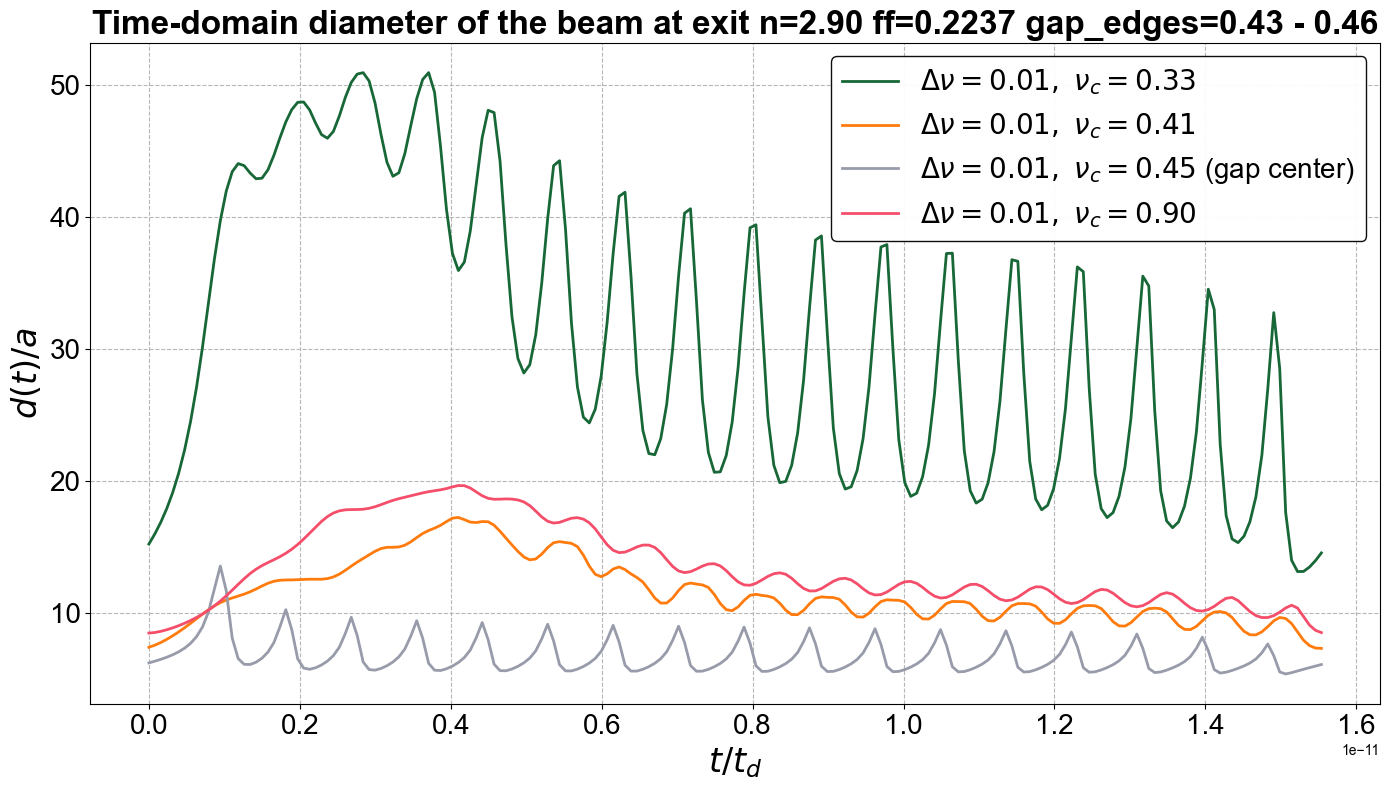

In [9]:

# --- time-domain beam diameter for a delta_nu = 0.025 window over the 20 ps run ---
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
delta_nu = 0.01
TARGET_NFFT = 200
fld = data["2.90"]
nu_full = a * np.asarray(fld["f"]) / td.C_0
for nu_center in [0.33,0.41, gap_center,0.9]:
    Nwin = int(np.sum((nu_full >= nu_center - delta_nu / 2) &
                       (nu_full <= nu_center + delta_nu / 2)))
    oversample = max(1, int(round(TARGET_NFFT / max(Nwin, 1))))
    t, d_t, nu_c, t_d = diameter_time_domain(data["2.90"], a, nu_center=nu_center, delta_nu=delta_nu,window="box",oversample=oversample,intensity_floor=0,diameter_type="participation_ratio")
    ax.plot(t,d_t, lw=2,
            label=rf"$\Delta\nu={delta_nu},\ \nu_c={nu_c:.2f}$" + (rf" (gap center)" if np.isclose(nu_c, gap_center) else ""))

ax.set_xlabel(r"$t/t_d$", fontsize=24, fontweight='bold')
ax.set_ylabel(r"$d(t)/a$", fontsize=24, fontweight='bold')  
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=20, framealpha=0.95, edgecolor='black')
# ax.set_xlim(0, 20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title(rf"Time-domain diameter of the beam at exit n=2.90 ff=0.2237 gap_edges={(a/gaps_ff_22_n_2p90)[0]:.2f} - {(a/gaps_ff_22_n_2p90)[1]:.2f}", fontsize=24, fontweight='bold')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## Time-domain diffusive baseline + expected size at $t\to\infty$

Counterpart of the steady-state benchmark in [20251008_IPR_Calculation.ipynb](20251008_IPR_Calculation.ipynb), for the reconstructed `d(t)`.

**Early-time baseline.** Without absorption the transverse mean-square width grows linearly (2-D random walk):
$$\langle r^2\rangle(t)=w_0^2+4\,D\,t,\qquad D=\tfrac13 v_E\,\ell^{*}.$$
We do **not** assume $D$ — it is read off from the early-time slope, and the data **bending below its own fit** is the localization signal (no absorption ⇒ not an absorption artefact, cf. Scheffold 1999). The $4Dt$ law is about the *second moment*, so the analysis uses `diameter_sigma` and plots $\langle r^2\rangle/a^2=(d_\sigma/2a)^2$, which is linear in $t$.

**Expected size at $t\to\infty$ *in a diffusive system*.** This is the key point of your question: **diffusion has no intrinsic confinement length**, so a non-localizing field keeps spreading until it fills the transverse aperture. With absorbing transverse edges the surviving long-time profile is the fundamental diffusion mode $\cos(\pi x/W_x)\cos(\pi y/W_y)$, whose $\langle r^2\rangle/a^2$ is the diffusive $t\to\infty$ size. **It is set by the box, not by the disorder, so it is the *same for every frequency*** (`diffusive_ceiling_msw`, ≈ 290 here, i.e. $\xi/a\approx17$; `mode='uniform'` gives the looser ceiling ≈ 750).

So the "expected size per frequency in a diffusive system" is a single horizontal ceiling. What is genuinely frequency-dependent is the **measured** saturation `plateau_msw` → $\xi(\nu)^2/a^2$: wherever it sits well **below** the diffusive ceiling (e.g. inside the gap) the mode is localized, and $\xi(\nu)=\sqrt{\langle r^2\rangle_\infty}$ is the localization length.

> Note this is the *time-resolved* $t\to\infty$ size. The complementary *CW / time-integrated* width is thickness-limited ($\sim L$) and is what `diffusive_diameter_slab` computes in the steady-state notebook — a different, smaller benchmark.

**Refs:** Sperling *et al.*, Nat. Photon. **7**, 48 (2013); Aegerter & Maret, Prog. Opt. **52**, 1 (2009); Scheffold *et al.*, Nature **398**, 206 (1999); van Albada *et al.*, PRL **66**, 3132 (1991). Full list in the steady-state notebook.


In [ ]:
# =====================================================================
#  Diffusive baseline for the TIME-DOMAIN spreading (no absorption)
# =====================================================================
# <r^2>(t) = w0^2 + 4 D t  (2D random walk, no absorption),  D = (1/3) v_E l*.
# Localization -> <r^2>(t) grows sub-linearly and saturates at ~ xi^2.
# The 4Dt law is about the SECOND MOMENT, so we use the sigma metric:
#   diameter_sigma = 2*sqrt(var_x+var_y) = 2*w  ->  <r^2>/a^2 = (d_sigma/(2a))^2.


def msw_time_domain(field, a, nu_center, delta_nu, oversample=1, window="box",
                    intensity_floor=1e-3):
    """Transverse mean-square width <r^2>(t)/a^2 for a frequency window, reusing
    `diameter_time_domain` with the sigma metric. A small `intensity_floor` is
    advised: the second moment is tail-sensitive, so far-field reconstruction
    noise must be clipped. Returns t (s), msw (a^2 units), nu_center, t_d."""
    t, d_sig_over_a, nu_c, t_d = diameter_time_domain(
        field, a, nu_center=nu_center, delta_nu=delta_nu, window=window,
        oversample=oversample, intensity_floor=intensity_floor,
        diameter_type="full_width_half_maximum")
    msw = (d_sig_over_a / 2.0) ** 2          # (d_sigma/2)^2 = <r^2>/a^2
    return t, msw, nu_c, t_d


def fit_diffusion_msw(t, msw, t_fit):
    """Linear fit  <r^2>/a^2 = c0 + (4D/a^2) t  on t_fit=(t_lo,t_hi).
    Returns (D [m^2/s], c0, line(t)).  a is in microns -> a*1e-6 m."""
    m = (t >= t_fit[0]) & (t <= t_fit[1]) & np.isfinite(msw)
    slope, c0 = np.polyfit(t[m], msw[m], 1)      # slope = 4D/a^2 [1/s]
    D = slope * (a * 1e-6) ** 2 / 4.0            # -> m^2/s
    return D, c0, (lambda tt: c0 + slope * np.asarray(tt, float))


def diffusive_width_time(t, D, w0=0.0):
    """Pure-diffusion transverse RMS width  w(t)=sqrt(w0^2+4 D t)  (no absorption,
    2D). API parity with the steady-state notebook."""
    return np.sqrt(w0 ** 2 + 4.0 * D * np.asarray(t, float))


# ---- Expected transverse size at t -> infinity IN A DIFFUSIVE SYSTEM ----------
# Diffusion has NO intrinsic confinement length, so a non-localizing field keeps
# spreading until it fills the transverse aperture. With absorbing transverse
# edges the longest-lived profile is the fundamental Dirichlet diffusion mode
# cos(pi x/Wx)cos(pi y/Wy); its <r^2>/a^2 is the diffusive t->inf size. It is set
# by the BOX, not the disorder -> SAME for every frequency. A measured plateau
# BELOW this ceiling is localization, its height = xi(nu)^2/a^2.


def diffusive_ceiling_msw(x, y, mode="fundamental"):
    """Expected t->inf transverse <r^2>/a^2 of a DIFFUSIVE (delocalized) field in
    the finite aperture (same second-moment metric as the data).
      mode='fundamental' : lowest Dirichlet diffusion mode (absorbing edges).
      mode='uniform'     : flat fill of the aperture (loose upper bound).
    Frequency-independent (geometry-set)."""
    X, Y = np.meshgrid(np.asarray(x, float), np.asarray(y, float), indexing="ij")
    Wx, Wy = x.max() - x.min(), y.max() - y.min()
    x0, y0 = 0.5 * (x.max() + x.min()), 0.5 * (y.max() + y.min())
    if mode == "fundamental":
        I = (np.cos(np.pi * (X - x0) / Wx) * np.cos(np.pi * (Y - y0) / Wy)) ** 2
    elif mode == "uniform":
        I = np.ones_like(X)
    else:
        raise ValueError(mode)
    return (diameter_sigma(I, x, y) / (2 * a)) ** 2


def plateau_msw(t, msw, t_d, frac=(0.55, 0.85)):
    """MEASURED t->inf saturation of <r^2>/a^2: mean over the late causal window
    [frac0,frac1]*T (after arrival t_d, before the FFT wrap at T). Returns
    (msw_inf, xi_over_a) with xi/a = sqrt(msw_inf). Compare to the ceiling:
    msw_inf << ceiling => localized."""
    T = t[-1]
    lo, hi = max(t_d, frac[0] * T), frac[1] * T
    m = (t >= lo) & (t <= hi) & np.isfinite(msw)
    msw_inf = float(np.nanmean(msw[m])) if m.any() else np.nan
    return msw_inf, np.sqrt(msw_inf)


In [ ]:
# --- Time-domain spreading: diffusive fit + expected size at t->inf -------------
# Per nu_center we show:
#   * <r^2>(t)/a^2 reconstructed (sigma metric),
#   * its early-time diffusive fit  <r^2> = w0^2 + 4 D t   (dashed),
#   * the DIFFUSIVE expectation at t->inf (black solid): a non-localizing field
#     fills the aperture -> geometry-set, SAME for every frequency,
#   * the MEASURED late-time plateau (dotted) = xi(nu)^2/a^2 if it sits below the
#     ceiling -> localization.
delta_nu = 0.025
TARGET_NFFT = 200
FIT_FRAC = 0.40          # fraction of the causal window used for the diffusive fit
CEILING_MODE = "fundamental"   # 'fundamental' (lowest diffusion mode) or 'uniform'
fld = data["2.90"]
nu_full = a * np.asarray(fld["f"]) / td.C_0

ceiling = diffusive_ceiling_msw(fld["x"], fld["y"], mode=CEILING_MODE)

fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
summary = []
for nu_center in [0.33, 0.41, gap_center, 0.9]:
    Nwin = int(np.sum((nu_full >= nu_center - delta_nu / 2) &
                      (nu_full <= nu_center + delta_nu / 2)))
    oversample = max(1, int(round(TARGET_NFFT / max(Nwin, 1))))
    t, msw, nu_c, t_d = msw_time_domain(fld, a, nu_center, delta_nu,
                                        oversample=oversample, window="box",
                                        intensity_floor=1e-3)
    T = t[-1]
    use = (t >= t_d) & (t <= 0.85 * T)                       # causal, no FFT wrap
    D, c0, line = fit_diffusion_msw(t, msw, (t_d, t_d + FIT_FRAC * (0.85 * T - t_d)))
    msw_inf, xi_over_a = plateau_msw(t, msw, t_d)

    p = ax.plot(t[use] * 1e12, msw[use], lw=2,
                label=rf"$\nu_c={nu_c:.2f}$" + (" (gap)" if np.isclose(nu_c, gap_center) else "")
                      + rf",  $\xi/a\approx{xi_over_a:.1f}$")
    col = p[0].get_color()
    ax.plot(t[use] * 1e12, line(t[use]), ls="--", lw=1.3, color=col, alpha=0.6)   # diffusive fit
    ax.axhline(msw_inf, ls=":", lw=1.6, color=col, alpha=0.9)                     # measured t->inf
    summary.append((nu_c, D, xi_over_a, msw_inf))

# diffusive expectation at t->inf (delocalized): fills the aperture, freq-independent
ax.axhline(ceiling, ls="-", lw=2.5, color="k", alpha=0.85,
           label=rf"diffusive $t\!\to\!\infty$ ({CEILING_MODE}): $\langle r^2\rangle/a^2={ceiling:.0f}$ ($\xi/a={np.sqrt(ceiling):.0f}$)")

ax.set_xlabel(r"$t$ (ps)", fontsize=24, fontweight='bold')
ax.set_ylabel(r"$\langle r^2\rangle / a^2$", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=12, framealpha=0.95, edgecolor='black')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title("Spreading vs diffusive baseline (dashed), measured $t\\to\\infty$ (dotted), diffusive ceiling (black)",
             fontsize=13, fontweight='bold')
ax.set_facecolor('white'); fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

print(f"{'nu_c':>6} {'D [m^2/s]':>12} {'xi/a (meas)':>12} {'<r^2>_inf/a^2':>15}   diffusive ceiling = {ceiling:.0f}")
for nu_c, D, xi, mi in summary:
    flag = "  <-- localized" if mi < 0.5 * ceiling else ""
    print(f"{nu_c:6.2f} {D:12.3e} {xi:12.2f} {mi:15.1f}{flag}")
